In [9]:
import pandas as pd
import numpy as np
import os

# Load in R-exported CSV with correct CBSA joins
df = pd.read_csv("/Users/brandonsmith/DATA-510-CAPSTONE--2/DATA-510-CAPSTONE--2/data/final_data/price_changes_with_collapse_flags.csv")

# replace dots in column names with underscores for easier acess
df.columns = df.columns.str.replace('.', '_', regex = False)

print(df.shape)
print(df.dtypes[['cbsa', 'metro_name_x', 'year', 'qtr']])

(83699, 25)
cbsa            int64
metro_name_x      str
year            int64
qtr             int64
dtype: object


/var/folders/8w/0g4j4t9j4jz3cfq3qwhrsn2r0000gn/T/ipykernel_2092/1113667877.py:6: DtypeWarning: Columns (0: RegionName.y) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/brandonsmith/DATA-510-CAPSTONE--2/DATA-510-CAPSTONE--2/data/final_data/price_changes_with_collapse_flags.csv")


In [10]:
# sanity check: confirming Austin (12420), Boise (14260), and Tampa (45294) all have data
training_cbsa_map = {'Austin': 12420.0, 'Boise': 14260.0, 'Tampa': 45294.0}

df = df.sort_values(['cbsa', 'year', 'qtr']).reset_index(drop=True)
g = df.groupby('cbsa')

df['is_unaffordable'] = df['price_to_income_ratio'] > 5.0
df['prev_unaffordable'] = g['is_unaffordable'].shift(1).fillna(False).astype(bool)
df['collapse_onset'] = df['is_unaffordable'] & (~df['prev_unaffordable'])

first_collapse = (
    df[df['collapse_onset']]
    .groupby('cbsa')[['metro_name_x', 'year', 'qtr', 'price_to_income_ratio']]
    .first()
)
print("Collapse onset check (training cities):")
print(first_collapse.loc[first_collapse.index.isin(training_cbsa_map.values())])
# this helps catches silent join failures before they cause problem in feature engineering

Collapse onset check (training cities):
                           metro_name_x  year  qtr  price_to_income_ratio
cbsa                                                                     
12420  Austin-Round Rock-San Marcos, TX  2021    2               5.194781
14260                    Boise City, ID  2019    3               5.046829
45294                  Tampa, FL (MSAD)  2021    4               5.213635


In [11]:
# testing to see how collapse onset date shifts if the threshold is 4.0, 4.5, 5.0 or 5.5
# Goal: confirm that 5.0 isn't an arbitry choise -- checck if a different threshold changes results signifcantly
for threshold in [4.0, 4.5, 5.0, 5.5]:
    print(f"\n--- Threshold: {threshold} ---")
    for city, code in training_cbsa_map.items():
        sub = df[df['cbsa'] == code].sort_values(['year', 'qtr']).copy()
        sub = sub[sub['price_to_income_ratio'].notna()]
        sub['is_unaffordable'] = sub['price_to_income_ratio'] > threshold
        sub['prev_unaffordable'] = sub['is_unaffordable'].shift(1).fillna(False)
        sub['onset'] = sub['is_unaffordable'] & ~sub['prev_unaffordable']
        onset_row = sub[sub['onset']].head(1)
        if len(onset_row) > 0:
            print(f"  {city}: {onset_row['year'].values[0]}Q{onset_row['qtr'].values[0]}")
        else:
            print(f"  {city}: never crosses this threshold")

# Results: 5.0 gives the tightest, most realistic cluster of onset dates for all three training cities


--- Threshold: 4.0 ---
  Austin: 2014Q3
  Boise: 2016Q2
  Tampa: 2017Q4

--- Threshold: 4.5 ---
  Austin: 2020Q4
  Boise: 2017Q4
  Tampa: 2021Q2

--- Threshold: 5.0 ---
  Austin: 2021Q2
  Boise: 2019Q3
  Tampa: 2021Q4

--- Threshold: 5.5 ---
  Austin: 2021Q3
  Boise: 2020Q4
  Tampa: 2022Q2


In [12]:
df = df.sort_values(['cbsa', 'year', 'qtr']).reset_index(drop=True)

df['is_unaffordable'] = df['price_to_income_ratio'] > 5.0
g = df.groupby('cbsa')
df['prev_unaffordable'] = g['is_unaffordable'].shift(1).fillna(False).astype(bool)
df['collapse_onset'] = df['is_unaffordable'] & (~df['prev_unaffordable'])

first_collapse = (
    df[df['collapse_onset']]
    .groupby('cbsa')[['metro_name_x', 'year', 'qtr', 'price_to_income_ratio']]
    .first()
) # final check: confirm onset dates still match austin 2021q2, boise 2019q3, Tampa, 2021q4
print(first_collapse.loc[first_collapse.index.isin(training_cbsa_map.values())])

                           metro_name_x  year  qtr  price_to_income_ratio
cbsa                                                                     
12420  Austin-Round Rock-San Marcos, TX  2021    2               5.194781
14260                    Boise City, ID  2019    3               5.046829
45294                  Tampa, FL (MSAD)  2021    4               5.213635


# Feature Enginnering
Every feature below is lagged by 4 quarters (1 year) before any rolling calcuation. This ensures no feature accidentally "sees" the same-quarter data used to build collapse_onset. 

# Rules
* never let a feature use current or future infro that overlaps with label construction

In [13]:
LAG = 4

df = df.sort_values(['cbsa', 'year', 'qtr']).reset_index(drop=True)
g = df.groupby('cbsa')

# Feature 1: price-to-income 5-year change
df['price_to_income_lag'] = g['price_to_income_ratio'].shift(LAG)
df['price_to_income_5yr_chg'] = df.groupby('cbsa')['price_to_income_lag'].transform(
    lambda x: x - x.shift(20)
)

# Feature 2: affordability momentum -- 3yr rolling slope of LAGGED zhvi_yoy
df['zhvi_yoy_fixed'] = df.groupby('cbsa')['zhvi_qtr'].transform(lambda x: x.pct_change(4))
df['zhvi_qoq_fixed'] = df.groupby('cbsa')['zhvi_qtr'].transform(lambda x: x.pct_change(1))
df['zhvi_yoy_lag'] = df.groupby('cbsa')['zhvi_yoy_fixed'].shift(LAG)
df['affordability_momentum'] = df.groupby('cbsa')['zhvi_yoy_lag'].transform(
    lambda x: x.rolling(12, min_periods=12).apply(
        lambda y: np.polyfit(np.arange(len(y)), y, 1)[0] if y.notna().all() else np.nan
    )
)
df['zhvi_qoq_lag'] = df.groupby('cbsa')['zhvi_qoq_fixed'].shift(LAG)

# Feature 3: hpi-based momentum (yoy change in index_sa)
df['hpi_yoy'] = df.groupby('cbsa')['index_sa'].transform(lambda x: x.pct_change(4))
df['hpi_yoy_lag'] = df.groupby('cbsa')['hpi_yoy'].shift(LAG)

# Secondary Signal (not in core feature set)
df['hpi_3yr_chg'] = g['index_sa'].transform(lambda x: (x / x.shift(12)) - 1) * 100

# Feature 4 & 5: population velocity and accleration , lagged
# Note: population coverage has a known gap for Tampa 
# These features are used for Austin/Boise and for the broader
# holdoutset, but not for unified Tampa-includsive model.
df["pop_yoy_fixed"] = g["population"].transform(lambda x: x.pct_change(4))
df["pop_velocity_fixed"] = df.groupby("cbsa")["pop_yoy_fixed"].diff()
df["pop_velocity_lag"] = df.groupby("cbsa")["pop_velocity_fixed"].shift(LAG)
df["pop_acceleration_fixed"] = df.groupby("cbsa")["pop_velocity_fixed"].diff()
df["pop_acceleration_lag"] = df.groupby("cbsa")["pop_acceleration_fixed"].shift(LAG)



In [14]:
# Coverage check

feature_cols = ['affordability_momentum', 'zhvi_qoq_lag', 'price_to_income_5yr_chg', 'hpi_yoy_lag']
pop_features = ['pop_velocity_lag', 'pop_acceleration_lag']

train_features = ["affordability_momentum", "zhvi_qoq_lag", "price_to_income_5yr_chg", "hpi_yoy_lag"]
pop_features = ["pop_velocity_lag", "pop_acceleration_lag"]

missing_cols = [c for c in train_features + pop_features + ["collapse_onset"] if c not in df.columns]
print("Missing engineered columns:", missing_cols)

print("\nTraining city coverage -- 4 core features:")
for city, code in training_cbsa_map.items():
    sub = df[df["cbsa"] == code]
    coverage = {col: int(sub[col].notna().sum()) for col in feature_cols}
    print(f"  {city}: {coverage}")

print("\nTraining city coverage -- population features:")
for city, code in training_cbsa_map.items():
    sub = df[df["cbsa"] == code]
    print(f"  {city}: pop_velocity_lag={sub['pop_velocity_lag'].notna().sum()}, "
          f"pop_acceleration_lag={sub['pop_acceleration_lag'].notna().sum()}")

holdout_check = df[~df["cbsa"].isin(training_cbsa_map.values())]
print("\nHoldout coverage -- 4 core features:")
for col in train_features:
    nonnull = holdout_check[col].notna()
    print(f"  {col}: {nonnull.sum()} rows, {holdout_check[nonnull]['cbsa'].nunique()} cities")

print("\nHoldout coverage -- population features:")
for col in pop_features:
    nonnull = holdout_check[col].notna()
    print(f"  {col}: {nonnull.sum()} rows, {holdout_check[nonnull]['cbsa'].nunique()} cities")

print("\nHoldout price_to_income_ratio non-null:", holdout_check["price_to_income_ratio"].notna().sum())
print("Holdout collapse_onset True count:", holdout_check["collapse_onset"].sum())


Missing engineered columns: []

Training city coverage -- 4 core features:
  Austin: {'affordability_momentum': 85, 'zhvi_qoq_lag': 99, 'price_to_income_5yr_chg': 40, 'hpi_yoy_lag': 187}
  Boise: {'affordability_momentum': 81, 'zhvi_qoq_lag': 95, 'price_to_income_5yr_chg': 40, 'hpi_yoy_lag': 179}
  Tampa: {'affordability_momentum': 145, 'zhvi_qoq_lag': 159, 'price_to_income_5yr_chg': 100, 'hpi_yoy_lag': 244}

Training city coverage -- population features:
  Austin: pop_velocity_lag=55, pop_acceleration_lag=54
  Boise: pop_velocity_lag=55, pop_acceleration_lag=54
  Tampa: pop_velocity_lag=0, pop_acceleration_lag=0

Holdout coverage -- 4 core features:
  affordability_momentum: 0 rows, 0 cities
  zhvi_qoq_lag: 0 rows, 0 cities
  price_to_income_5yr_chg: 0 rows, 0 cities
  hpi_yoy_lag: 66325 rows, 407 cities

Holdout coverage -- population features:
  pop_velocity_lag: 19805 rows, 371 cities
  pop_acceleration_lag: 19434 rows, 371 cities

Holdout price_to_income_ratio non-null: 0
Holdout 

# Findings
* price_to_income_ratio, and therefor collapse_onset as TRUE
* label, exists ONLY for Austin, Boise, and Tampa - no other metro
* has grounded-truth collpase lables in this data set. hii_yoy_lag and the population features DO have broad multi-city coverage, so they can be used to SCORE risk in other metros, but any resulting scores cannot be validated against a true label
* this remains consistent with the early-warning framing of this research question

In [15]:
# Create output directory if it doesn't exist
os.makedirs("output", exist_ok=True)


# Model 1 data: explantory (3 training cities, 4 features)
# filtering the rows for the 3 training cities with no missing feature/target values
model1_df = df[df["cbsa"].isin(training_cbsa_map.values())].dropna(
    subset=train_features + ["collapse_onset"]
).copy()

# running total of collapse_onset per city, used to split pre vs post-collapse periods
model1_df["cum_onset"] = model1_df.groupby("cbsa")["collapse_onset"].cumsum()

# training set: only rows before the first collapse_onset flag (cum_onset still 0)
model1_train = model1_df[model1_df["cum_onset"] == 0]

# validation set: rows at or after the collapse_onset event (cum_onset > 0)
model1_val = model1_df[model1_df["cum_onset"] > 0]

# sanity check
print("Model 1 -- training rows (pre-collapse, 3 cities):", len(model1_train))
print("Model 1 -- validation rows (collapse onset+, 3 cities):", len(model1_val))

# save both splits to csvs for reuse in modeling steps
model1_train.to_csv("output/model1_train.csv", index=False)
model1_val.to_csv("output/model1_val.csv", index=False)

Model 1 -- training rows (pre-collapse, 3 cities): 105
Model 1 -- validation rows (collapse onset+, 3 cities): 75


In [16]:
# Model 2 data: generalization/scoring (Austin+Boise, 3 features)
# reduce feature set used for the scoring model (drops one feature vs. model 1)
scoring_features = ["hpi_yoy_lag", "pop_velocity_lag", "pop_acceleration_lag"]
# only austin and boise this time (tampa excluded for this model)
model2_train_cities = {"Austin": training_cbsa_map["Austin"], "Boise": training_cbsa_map["Boise"]}

# filter to austin+ boise rows with no missing feature/target values
model2_df = df[df["cbsa"].isin(model2_train_cities.values())].dropna(
    subset=scoring_features + ["collapse_onset"]
).copy()

# running total of collapse_onset per city, used to split pre- vs post-collapse periods
model2_df["cum_onset"] = model2_df.groupby("cbsa")["collapse_onset"].cumsum()

# training set: rows before each city's first collapse_onset flag
model2_train = model2_df[model2_df["cum_onset"] == 0]

# validation set: rows at or after collapse_onset
model2_val = model2_df[model2_df["cum_onset"] > 0]

# quick sanity check
print("\nModel 2 -- training rows (Austin+Boise pre-collapse):", len(model2_train))
print("Model 2 -- validation rows (Austin+Boise collapse onset+):", len(model2_val))

# save both splits to CSv for resuse in modeling steps
model2_train.to_csv("output/model2_train.csv", index=False)
model2_val.to_csv("output/model2_val.csv", index=False)


Model 2 -- training rows (Austin+Boise pre-collapse): 63
Model 2 -- validation rows (Austin+Boise collapse onset+): 45


In [17]:
# holdout score set: ( all other meros, 3 features, no labels)
# exclude the 3 training cities (tampa, austin, boise) - everything else is a candidate for scoring
holdout_scoring = df[~df["cbsa"].isin(training_cbsa_map.values())].dropna(
    subset=scoring_features
).copy()

# quicky sanity check on holdout set size and city coverage
print("\nHoldout scoring rows:", len(holdout_scoring), "| cities:", holdout_scoring["cbsa"].nunique())

# save holdout set for later scoring with the trained model
holdout_scoring.to_csv("output/holdout_scoring.csv", index=False)

# confirm all output files were written
print("\nSaved: model1_train.csv, model1_val.csv, model2_train.csv, model2_val.csv, holdout_scoring.csv")


Holdout scoring rows: 19432 | cities: 371

Saved: model1_train.csv, model1_val.csv, model2_train.csv, model2_val.csv, holdout_scoring.csv


# Phase 5: modeling (xgboost) + shap explainability

In [18]:
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, make_scorer, precision_recall_curve
)

In [19]:
os.makedirs("output/figures", exist_ok=True)
os.makedirs("output/tables", exist_ok=True)

train_features = ["affordability_momentum", "zhvi_qoq_lag", "price_to_income_5yr_chg", "hpi_yoy_lag"]
score_features = ["hpi_yoy_lag", "pop_velocity_lag", "pop_acceleration_lag"]
target = "collapse_onset"

In [20]:
# loading in data
model1_train = pd.read_csv("output/model1_train.csv")
model1_val = pd.read_csv("output/model1_val.csv")
model2_train = pd.read_csv("output/model2_train.csv")
model2_val = pd.read_csv("output/model2_val.csv")
holdout_scoring = pd.read_csv("output/holdout_scoring.csv")

In [21]:
# model 1 - explaintoy model (austin/boise/tampa, 4 features) - small sample (58 train / 62 val),
# so the model shallow to avoid overfitting. this model is for shap explainability, not for generating production risk scores

from sklearn.model_selection import train_test_split

target = "is_unaffordable"
model1_pool = df[df["cbsa"].isin(training_cbsa_map.values())].dropna(subset=train_features + [target]).copy()

X_all = model1_pool[train_features]
y_all = model1_pool[target].astype(int)

Xa_train, Xa_val, ya_train, ya_val = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all
)

print("Fresh split — train:", ya_train.value_counts().to_dict())
print("Fresh split — val:", ya_val.value_counts().to_dict())
print("Overlap check:", ya_val.index.isin(ya_train.index).sum())
print("Matches old model1_val?", Xa_val.equals(model1_val[train_features]) if 'model1_val' in dir() else "n/a")

model1_fresh = xgb.XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42
)
model1_fresh.fit(Xa_train, ya_train)

pred_fresh = model1_fresh.predict(Xa_val)
proba_fresh = model1_fresh.predict_proba(Xa_val)[:, 1]

print("\nFresh Model 1 metrics:")
print({
    "accuracy": accuracy_score(ya_val, pred_fresh),
    "precision": precision_score(ya_val, pred_fresh, zero_division=0),
    "recall": recall_score(ya_val, pred_fresh, zero_division=0),
    "f1": f1_score(ya_val, pred_fresh, zero_division=0),
    "roc_auc": roc_auc_score(ya_val, proba_fresh)
})
print(classification_report(ya_val, pred_fresh))

Fresh split — train: {0: 85, 1: 41}
Fresh split — val: {0: 37, 1: 17}
Overlap check: 0
Matches old model1_val? False

Fresh Model 1 metrics:
{'accuracy': 0.9074074074074074, 'precision': 0.8333333333333334, 'recall': 0.8823529411764706, 'f1': 0.8571428571428571, 'roc_auc': 0.9427662957074722}
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        37
           1       0.83      0.88      0.86        17

    accuracy                           0.91        54
   macro avg       0.89      0.90      0.89        54
weighted avg       0.91      0.91      0.91        54



In [36]:
import os
os.makedirs("output/tables", exist_ok=True)

model1_metrics = pd.DataFrame([{
    "model": "Model 1 (explanatory, target=is_unaffordable)",
    "accuracy": 0.9074074074074074,
    "precision": 0.8333333333333334,
    "recall": 0.8823529411764706,
    "f1": 0.8571428571428571,
    "roc_auc": 0.9427662957074722
}])
model1_metrics.to_csv("output/tables/model1_metrics_final.csv", index=False)
print("Saved output/tables/model1_metrics_final.csv")

Saved output/tables/model1_metrics_final.csv


In [24]:
explainer = shap.TreeExplainer(model1_fresh)
shap_values = explainer.shap_values(Xa_train)

print("shap_values shape:", np.array(shap_values).shape)

plt.figure()
shap.summary_plot(shap_values, Xa_train, show=False)
plt.tight_layout()
plt.savefig("output/figures/shap_summary_model1.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved output/figures/shap_summary_model1.png")

shap_importance = pd.DataFrame({
    "feature": train_features,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)
shap_importance.to_csv("output/tables/shap_importance_model1.csv", index=False)
print(shap_importance)

shap_values shape: (126, 4)
Saved output/figures/shap_summary_model1.png
                   feature  mean_abs_shap
2  price_to_income_5yr_chg       1.082847
0   affordability_momentum       0.702496
3              hpi_yoy_lag       0.588281
1             zhvi_qoq_lag       0.137570


In [25]:
scoring_features = ["hpi_yoy_lag", "pop_velocity_lag", "pop_acceleration_lag"]
target = "is_unaffordable"

model2_train_cities = {
    "Austin": training_cbsa_map['Austin'],
    "Boise": training_cbsa_map['Boise'],
}

model2_pool = df[df['cbsa'].isin(model2_train_cities.values())].dropna(subset=scoring_features + [target]).copy()

print("model 2 pool size:", len(model2_pool))
print("label distribution: \n", model2_pool[target].value_counts())

Xb_all = model2_pool[scoring_features]
yb_all = model2_pool[target].astype(int)

Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    Xb_all, yb_all, test_size=0.3, random_state=42, stratify=yb_all
)

print("train distribution: \n", yb_train.value_counts())
print("val distribution: \n", yb_val.value_counts())
print("overlap check:", yb_val.index.isin)

model 2 pool size: 108
label distribution: 
 is_unaffordable
False    76
True     32
Name: count, dtype: int64
train distribution: 
 is_unaffordable
0    53
1    22
Name: count, dtype: int64
val distribution: 
 is_unaffordable
0    23
1    10
Name: count, dtype: int64
overlap check: <bound method Index.isin of Index([5066, 8936, 5098, 5046, 8953, 8970, 5074, 5068, 8956, 8934, 8928, 8948,
       8954, 8943, 5071, 5077, 5065, 8945, 8968, 5069, 8925, 5056, 5092, 8951,
       8963, 5047, 8937, 8972, 8959, 5059, 8962, 8929, 5088],
      dtype='int64')>


In [33]:
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

best_f1, best_t = 0, 0.5
for t in np.arange(0.1, 0.9, 0.01):
    pred_t = (proba2 >= t).astype(int)
    f1_t = f1_score(yb_val, pred_t, zero_division=0)
    if f1_t > best_f1:
        best_f1, best_t = f1_t, t

pred_final = (proba2 >= best_t).astype(int)
print(f"[Threshold moving] Optimal threshold: {best_t:.2f}")
print("Precision:", precision_score(yb_val, pred_final, zero_division=0))
print("Recall:", recall_score(yb_val, pred_final, zero_division=0))
print("F1:", best_f1)
print(classification_report(yb_val, pred_final))

neg, pos = (yb_all == 0).sum(), (yb_all == 1).sum()
spw_ratio = neg / pos
print("\nClass ratio (neg/pos):", spw_ratio)

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, spw_ratio * 1.5),
        "eval_metric": "logloss",
        "random_state": 42
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, Xb_all, yb_all, scoring="f1", cv=cv)
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100)

print("\n[Re-tuned with scale_pos_weight]")
print("Best params:", study.best_params)
print("Best CV F1:", study.best_value)

model2_final = xgb.XGBClassifier(**study.best_params, eval_metric="logloss", random_state=42)
model2_final.fit(Xb_train, yb_train)

pred2_final = model2_final.predict(Xb_val)
proba2_final = model2_final.predict_proba(Xb_val)[:, 1]

print("\nFinal Model 2 metrics:")
print({
    "accuracy": accuracy_score(yb_val, pred2_final),
    "precision": precision_score(yb_val, pred2_final, zero_division=0),
    "recall": recall_score(yb_val, pred2_final, zero_division=0),
    "f1": f1_score(yb_val, pred2_final, zero_division=0),
    "roc_auc": roc_auc_score(yb_val, proba2_final)
})
print(classification_report(yb_val, pred2_final))

[I 2026-07-11 10:02:48,456] A new study created in memory with name: no-name-60924844-b9e5-4c7b-bc43-2ea35de82fe5


[Threshold moving] Optimal threshold: 0.24
Precision: 0.5
Recall: 0.6
F1: 0.5454545454545454
              precision    recall  f1-score   support

           0       0.81      0.74      0.77        23
           1       0.50      0.60      0.55        10

    accuracy                           0.70        33
   macro avg       0.65      0.67      0.66        33
weighted avg       0.72      0.70      0.70        33


Class ratio (neg/pos): 2.375


[I 2026-07-11 10:02:48,857] Trial 0 finished with value: 0.5611032105149752 and parameters: {'max_depth': 3, 'min_child_weight': 7, 'learning_rate': 0.07259248719561363, 'n_estimators': 140, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.0349658373387986e-08, 'reg_lambda': 0.6245760287469887, 'scale_pos_weight': 2.5403572175919726}. Best is trial 0 with value: 0.5611032105149752.
[I 2026-07-11 10:02:49,950] Trial 1 finished with value: 0.4357489878542511 and parameters: {'max_depth': 4, 'min_child_weight': 1, 'learning_rate': 0.13826189316223855, 'n_estimators': 175, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'reg_alpha': 3.3300161336615e-07, 'reg_lambda': 5.472429642032189e-06, 'scale_pos_weight': 2.3446883560576093}. Best is trial 0 with value: 0.5611032105149752.
[I 2026-07-11 10:02:50,308] Trial 2 finished with value: 0.4277698771816419 and parameters: {'max_depth': 3, 'min_child_weight': 3, 'learning_rate': 0.05


[Re-tuned with scale_pos_weight]
Best params: {'max_depth': 4, 'min_child_weight': 6, 'learning_rate': 0.05000941294705251, 'n_estimators': 75, 'subsample': 0.6819292371595461, 'colsample_bytree': 0.912717608579208, 'reg_alpha': 3.7072086749017556e-05, 'reg_lambda': 3.3073309580502154e-06, 'scale_pos_weight': 2.1339466023246993}
Best CV F1: 0.6081385281385281

Final Model 2 metrics:
{'accuracy': 0.7878787878787878, 'precision': 0.7142857142857143, 'recall': 0.5, 'f1': 0.5882352941176471, 'roc_auc': 0.7130434782608697}
              precision    recall  f1-score   support

           0       0.81      0.91      0.86        23
           1       0.71      0.50      0.59        10

    accuracy                           0.79        33
   macro avg       0.76      0.71      0.72        33
weighted avg       0.78      0.79      0.78        33



In [35]:
model2_metrics = pd.DataFrame([{
    "model": "Model 2 (generalization/scoring)",
    "cities": "Austin, Boise",
    "features": "hpi_yoy_lag, pop_velocity_lag, pop_acceleration_lag",
    "accuracy": 0.7878787878787878,
    "precision": 0.7142857142857143,
    "recall": 0.5,
    "f1": 0.5882352941176471,
    "roc_auc": 0.7130434782608697
}])

model2_metrics.to_csv("output/tables/model2_metrics_final.csv", index=False)
print("Saved output/tables/model2_metrics_final.csv")

Saved output/tables/model2_metrics_final.csv


# 65-city holdout set

In [76]:
import os
os.makedirs("output/tables", exist_ok=True)

holdout_scoring = pd.read_csv("output/holdout_scoring.csv")
holdout_scoring["risk_score"] = model2_fresh.predict_proba(holdout_scoring[scoring_features])[:, 1]

city_risk = (
    holdout_scoring.groupby(["cbsa", "metro_name_x"])["risk_score"]
    .mean().reset_index().sort_values("risk_score", ascending=False)
)

city_risk.to_csv("output/tables/holdout_city_risk_scores.csv", index=False)
print("Saved output/tables/holdout_city_risk_scores.csv")
print("\ntop 15 highest-risk metros:")
print(city_risk.head(15))

Saved output/tables/holdout_city_risk_scores.csv

top 15 highest-risk metros:
      cbsa                           metro_name_x  risk_score
41   14580                            Bozeman, MT    0.570732
315  43640       Slidell-Mandeville-Covington, LA    0.470978
142  25740                             Helena, MT    0.461148
221  33500                              Minot, ND    0.460481
333  45900                      Traverse City, MI    0.449701
11   11200           Amherst Town-Northampton, MA    0.442434
252  37140                         Paducah, KY-IL    0.439345
298  41780                           Sandusky, OH    0.427475
259  38240           Pinehurst-Southern Pines, NC    0.416907
172  28450                            Kenosha, WI    0.412102
66   17410                          Cleveland, OH    0.400774
351  47930                  Waterbury-Shelton, CT    0.380663
176  28880  Kiryas Joel-Poughkeepsie-Newburgh, NY    0.379746
196  30500                     Lexington Park, MD    0

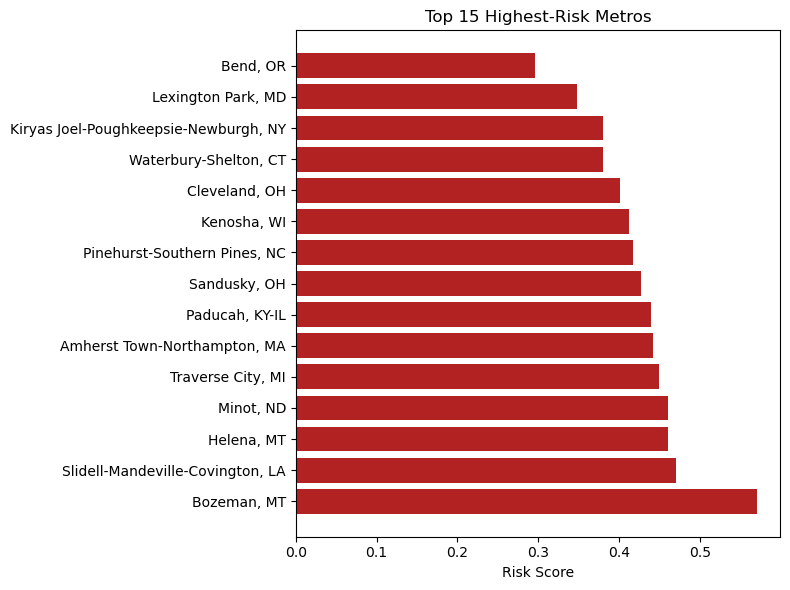

saved output/figures/top15_highest_risk_metros.png


In [58]:
top15 = city_risk.head(15).sort_values("risk_score", ascending=False)
plt.figure(figsize = (8,6))
plt.barh(top15['metro_name_x'], top15['risk_score'], color="firebrick")
plt.xlabel("Risk Score")
plt.title("Top 15 Highest-Risk Metros")
plt.tight_layout()
plt.show()
plt.savefig("output/figures/top15_highest_risk_metros.png", dpi=150, bbox_inches="tight")
plt.close()
print("saved output/figures/top15_highest_risk_metros.png")

# Validation Testing


In [59]:
# model 1: k-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
f1_scorer = make_scorer(f1_score, zero_division=0)

cv_model1 = xgb.XGBClassifier(
    n_estimators = 100, 
    max_depth = 3, 
    learning_rate = 0.05, 
    subsample = 0.8,
    colsample_bytree = 0.8,
    eval_metric = 'logloss',
    random_state = 42
    )

f1_scores_m1 = cross_val_score(cv_model1, X_all, y_all, cv=cv, scoring=f1_scorer)
auc_scores_m1 = cross_val_score(cv_model1, X_all, y_all, cv=cv, scoring="roc_auc")

print("Model 1: 5-fold cross-validation")
print(f"f1 scores per fold: {np.round(f1_scores_m1,3)}")
print(f"mean f1 score: {np.round(f1_scores_m1.mean(),3)}")
print(f"AUC scores per fold: {np.round(auc_scores_m1,3)}")
print(f"mean AUC score: {np.round(auc_scores_m1.mean(),3)}")

# model 2: k-fold cross-validation
cv_model2 = xgb.XGBClassifier(
    n_estimators = 100, 
    max_depth = 3,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    eval_metric = 'logloss',
    random_state = 42
)

f1_scores_m2 = cross_val_score(cv_model2, Xb_all, yb_all, cv=cv, scoring=f1_scorer)
auc_scores_m2 = cross_val_score(cv_model2, Xb_all, yb_all, cv=cv, scoring="roc_auc")

print("Model 2: 5-fold cross-validation")
print(f"f1 scores per fold: {np.round(f1_scores_m2,3)}")
print(f"mean f1 score: {np.round(f1_scores_m2.mean(),3)}")
print(f"AUC scores per fold: {np.round(auc_scores_m2,3)}")
print(f"mean AUC score: {np.round(auc_scores_m2.mean(),3)}")

cv_results = pd.DataFrame({
    "model": ["model 1"] * 5 + ["model 2"] * 5,
    "fold": list(range(1, 6)) * 2,
    "f1": list(f1_scores_m1) + list(f1_scores_m2),
    "roc_auc": list(auc_scores_m1) + list(auc_scores_m2)
})
cv_results.to_csv("output/tables/cv_results_final.csv", index=False)
print("\nSaved output/tables/cv_results_final.csv")

Model 1: 5-fold cross-validation
f1 scores per fold: [0.625 0.8   0.545 0.632 0.762]
mean f1 score: 0.673
AUC scores per fold: [0.829 0.953 0.851 0.938 0.924]
mean AUC score: 0.899
Model 2: 5-fold cross-validation
f1 scores per fold: [0.    0.364 0.5   0.4   0.923]
mean f1 score: 0.437
AUC scores per fold: [0.792 0.624 0.576 0.7   1.   ]
mean AUC score: 0.738

Saved output/tables/cv_results_final.csv


# SHAP explainability

In [60]:
# model 1

model1_full = xgb.XGBClassifier(
    n_estimators = 100, 
    max_depth = 3, 
    learning_rate = 0.05, 
    subsample = 0.8,
    colsample_bytree = 0.8,
    eval_metric = 'logloss',
    random_state = 42
)

model1_full.fit(X_all, y_all)

explainer1 = shap.TreeExplainer(model1_full)
shap_values1 = explainer1.shap_values(X_all)

plt.figure()
shap.summary_plot(shap_values1, X_all, plot_type = "bar", show=False)
plt.title("model 1")
plt.tight_layout()
plt.savefig("output/figures/shap_summary_model1_full.png", dpi=150,)
plt.close()

plt.figure()
shap.summary_plot(shap_values1, X_all, show=False)
plt.title("model 1")
plt.tight_layout()
plt.savefig("output/figures/shap_summary_model1_beeswarm_full.png", dpi=150,)
plt.close()

print("model 1 SHAP plots saved.")


model 1 SHAP plots saved.


In [61]:
# model 2

model2_full = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3, 
    learning_rate=0.05,
    subsample=0.8, 
    colsample_bytree=0.8, 
    eval_metric="logloss", 
    random_state=42
)
model2_full.fit(Xb_all, yb_all)

explainer2 = shap.TreeExplainer(model2_full)
shap_values2 = explainer2.shap_values(Xb_all)

plt.figure()
shap.summary_plot(shap_values2, Xb_all, plot_type = "bar", show=False)
plt.title("model 2")
plt.tight_layout()
plt.savefig("output/figures/shap_summary_model2_full.png", dpi=150,)
plt.close()

plt.figure()
shap.summary_plot(shap_values2, Xb_all, show=False)
plt.title("model 2")
plt.tight_layout()
plt.savefig("output/figures/shap_summary_model2_beeswarm_full.png", dpi=150,)
plt.close()

print("model 2 SHAP plots saved.")

model 2 SHAP plots saved.


# Backtesting

In [62]:
# model 1
from statsmodels.discrete.discrete_model import Logit
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

X_train_const = X_train.copy()
X_train_const.insert(0, "const", 1.0)
X_test_const = X_test.copy()
X_test_const.insert(0, "const", 1.0)

logit_model1 = Logit(y_train, X_train_const)
result1 = logit_model1.fit(disp=0)

pred_probs1 = result1.predict(X_test_const)
auc1 = roc_auc_score(y_test, pred_probs1)

print("model 1 backtest" )
print(result1.summary())
print(f"\nbacktest AUC: {auc1:.3f}")

model 1 backtest
                           Logit Regression Results                           
Dep. Variable:        is_unaffordable   No. Observations:                  144
Model:                          Logit   Df Residuals:                      139
Method:                           MLE   Df Model:                            4
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:                  0.2509
Time:                        20:20:46   Log-Likelihood:                -67.575
converged:                       True   LL-Null:                       -90.209
Covariance Type:            nonrobust   LLR p-value:                 3.498e-09
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.6812      0.499     -5.374      0.000      -3.659      -1.703
affordability_momentum    -24.3460     17.459     -1.395      0.163     -58

In [63]:
# model 2
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb_all, yb_all, test_size=0.2, random_state=42, stratify=yb_all
)

Xb_train_const = Xb_train.copy()
Xb_train_const.insert(0, "const", 1.0)
Xb_test_const = Xb_test.copy()
Xb_test_const.insert(0, "const", 1.0)

logit_model2 = Logit(yb_train, Xb_train_const)
result2 = logit_model2.fit(disp=0)

pred_probs2 = result2.predict(Xb_test_const)
auc2 = roc_auc_score(yb_test, pred_probs2)

print("model 2", result2.model.exog_names)
print("model 2 backtest ")
print(result2.summary())
print(f"\nbacktest AUC: {auc2:.3f}")

model 2 ['const', 'hpi_yoy_lag', 'pop_velocity_lag', 'pop_acceleration_lag']
model 2 backtest 
                           Logit Regression Results                           
Dep. Variable:        is_unaffordable   No. Observations:                   86
Model:                          Logit   Df Residuals:                       82
Method:                           MLE   Df Model:                            3
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:                  0.2398
Time:                        20:20:48   Log-Likelihood:                -39.409
converged:                       True   LL-Null:                       -51.839
Covariance Type:            nonrobust   LLR p-value:                 1.652e-05
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.0673      0.406     -5.087      0.000      -2.864      -1.271
hpi_yo